# SMICA: Joint HI + Foreground Covariance Fit

Combines the two pieces built separately elsewhere in this repo into a single pipeline:

- **`SMICA_HI.ipynb`**: a *parametric* model for the HI angular power spectrum, $C^{HI}_\ell(\nu)$, built from a
  log-$\ell$ polynomial times a frequency-dependent trapezoidal basis, fit by maximum-likelihood spectral matching.
- **`smica_test.ipynb`**: a *blind, low-rank* model for the foreground frequency covariance,
  $R_{fg}(\ell) = F\,P_b(\ell)\,F^\top$ with $F$ a $(n_\nu \times r)$ mixing matrix, exploiting the fact that
  synchrotron + free-free are smooth and highly correlated across frequency.

Both notebooks previously treated the *other* component as truth (SMICA_HI used the true simulated
foreground covariance; smica_test used the true simulated HI covariance). Here both are **unknown and fit
jointly** in one spectral-matching maximum-likelihood step:

$$C_{\rm model}(\ell) = C_{\rm HI}(\ell;\,a) + C_{\rm noise}(\ell) + F\,P_b(\ell)\,F^\top$$

with only the noise covariance treated as known (theory noise). The joint parameter
vector is $\theta = (a,\,F,\,L_b)$ where $P_b = L_bL_b^\top$ enforces positive-semidefiniteness.

The true HI and foreground maps are still loaded below, but **only for validation plots** -- they never enter
the fit itself.

In [3]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import pymaster as nmt
from scipy import optimize
from numpy.linalg import slogdet
from itertools import product
import sys
sys.path.append('../')

from scripts.compute_covariance import compute_covariance
from scripts.mask_maps import mask_maps

input_path = "/datadec/cppm/shoaib/SMICA_Paper/data"


In [94]:
nside = 256
npix = hp.nside2npix(nside)
freqs = np.arange(544, 1088, step=10)  # MHz
nfreqs = len(freqs) - 1
lmax = 3 * nside - 1
ells = np.arange(2, lmax + 1)
almsize = hp.Alm.getsize(lmax)

r = 3            # foreground model rank
bin_width = 10   # ell bin width for pseudo-Cl binning
bins = 8        # number of frequency trapezoidal basis functions for the HI model


## Helper functions

In [74]:
def apply_mask_with_nan(data, mask):
    """Apply mask to data, setting masked regions (mask==0) to NaN for better visualization."""
    masked_data = data * mask
    masked_data[mask == 0] = np.nan
    return masked_data


def rotate_maps(map: np.ndarray) -> np.ndarray:
    """Convert maps frequency by frequency from galactic to celestial/equatorial coordinates."""
    rot = hp.rotator.Rotator(coord=['G', 'C'])
    rotated = np.zeros_like(map)
    for i in range(nfreqs):
        print(f"Rotating map {i+1}")
        rotated[i] = rot.rotate_map_alms(map[i])
    return rotated


def bin_spectra(cl, nside, delta):
    b = nmt.NmtBin.from_lmax_linear(lmax, nlb=delta)
    nbins = b.get_n_bands()
    leff = b.get_effective_ells()
    cl_binned = np.zeros((nbins, nfreqs, nfreqs))
    for i in range(nfreqs):
        for j in range(nfreqs):
            cl_binned[:, i, j] = b.bin_cell(cl[:, i, j])
    return leff, nbins, cl_binned


def normalize_covariance_by_sky_fraction(mask, fgds_cl, hi_cl, noise_cl, sky_cl):
    """Normalize covariance matrices by the sky fraction."""
    fsky = mask.mean()
    pseudo_fgds_cl = fgds_cl / fsky
    pseudo_hi_cl = hi_cl / fsky
    pseudo_noise_cl = noise_cl / fsky
    pseudo_sky_cl = sky_cl / fsky
    return fsky, pseudo_fgds_cl, pseudo_hi_cl, pseudo_noise_cl, pseudo_sky_cl


def build_trapezoidal_basis(freqs, n_bins, top_width=0.5):
    """Trapezoidal basis functions (___/----\\___) on the frequency grid."""
    nf = len(freqs)
    vmin, vmax = freqs[0], freqs[-1]
    bin_edges = np.linspace(vmin, vmax, n_bins + 1)
    bwidth = bin_edges[1] - bin_edges[0]
    flat_top = top_width * bwidth
    slope_width = (1 - top_width) * bwidth / 2

    phi = np.zeros((n_bins, nf))
    for i in range(n_bins):
        left = bin_edges[i] - slope_width
        start_flat = bin_edges[i]
        end_flat = bin_edges[i + 1]
        right = bin_edges[i + 1] + slope_width
        for j, v in enumerate(freqs):
            if left <= v < start_flat:
                phi[i, j] = (v - left) / slope_width
            elif start_flat <= v <= end_flat:
                phi[i, j] = 1.0
            elif end_flat < v <= right:
                phi[i, j] = (right - v) / slope_width
            else:
                phi[i, j] = 0.0
    return phi


def pca_init(empirical, rank):
    """Initialize F, P_b for the rank-r foreground model from the top eigenvectors of the mean covariance."""
    R_global = np.mean(empirical, axis=0)
    eigvals, eigvecs = np.linalg.eigh(R_global)  # ascending order
    F_i = eigvecs[:, -rank:]
    eigvals_r = np.clip(eigvals[-rank:], a_min=1e-15, a_max=None)
    P_b_i = np.array([np.diag(eigvals_r) for _ in range(empirical.shape[0])])
    for b in range(empirical.shape[0]):
        proj = F_i.T @ empirical[b] @ F_i
        P_b_i[b] = 0.5 * (proj + proj.T)
    return F_i, P_b_i


## Mask
Create a patch of sky near the south pole (same footprint used in both source notebooks).

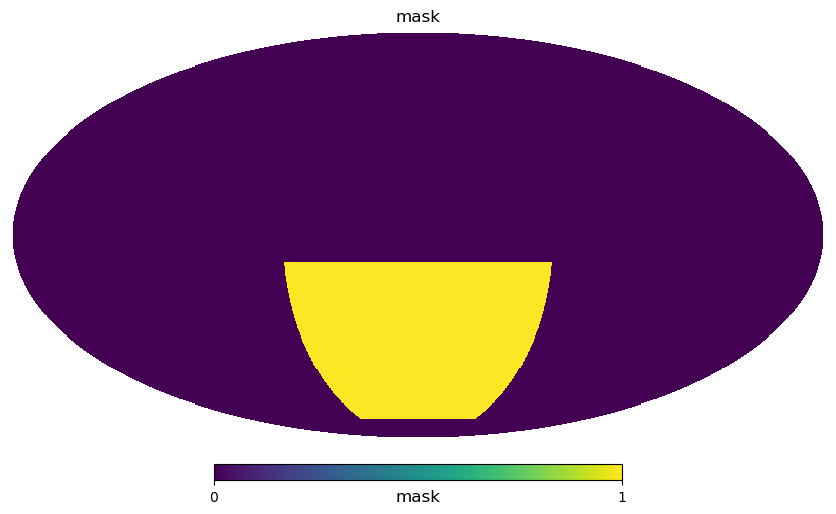

In [75]:
def create_sky_patch_mask(nside, ra_min, ra_max, dec_min, dec_max):
    """Create a rectangular sky patch mask in HEALPix format."""
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix), lonlat=False)
    ra = np.degrees(phi)
    dec = 90.0 - np.degrees(theta)
    ra = ((ra + 180) % 360) - 180
    mask = (
        (ra >= ra_min) & (ra <= ra_max) &
        (dec >= dec_min) & (dec <= dec_max)
    ).astype(np.uint8)
    return mask


mask = create_sky_patch_mask(nside=256, ra_min=-60.0, ra_max=60.0, dec_min=-75.0, dec_max=-10.0)
hp.mollview(mask, title="mask", unit="mask")


## Load simulated maps

In [76]:
ff = np.load(f"{input_path}/smoothed_ff_maps.npy") * 1e-3     # mK
sync = np.load(f"{input_path}/smoothed_sync_maps.npy") * 1e-3  # mK
noise = np.load(f"{input_path}/noise_maps.npy")[:-1] * 1e3     # mK

hi_cl2 = np.load(f"{input_path}/cal_hi_cov_mK.npy")
cl_hi = np.transpose(hi_cl2, (2, 0, 1))
hi_maps = np.load(f"{input_path}/hi_maps_mK.npy")

fgds = ff + sync
signal = fgds + hi_maps[:-1] + noise


## Rotate to equatorial coordinates

Rotating with alms (not pixel interpolation) avoids the resampling error that pixel-space rotation introduces.
The rotated maps are precomputed and cached, as in the source notebooks.

In [8]:
rotated_fgds = np.load(f"{input_path}/rotated_fgds.npy")
rotated_hi = np.load(f"{input_path}/rotated_hi.npy")
rotated_noise = np.load(f"{input_path}/rotated_noise.npy")
rotated_sky = np.load(f"{input_path}/rotated_sky.npy")


## Mask maps and compute covariances

In [9]:
fgds_masked, _ = mask_maps(rotated_fgds, mask, almsize, lmax, nfreqs, npix)
hi_masked, _ = mask_maps(rotated_hi, mask, almsize, lmax, nfreqs, npix)
noise_masked, _ = mask_maps(rotated_noise, mask, almsize, lmax, nfreqs, npix)
sky_masked, _ = mask_maps(rotated_sky, mask, almsize, lmax, nfreqs, npix)


In [10]:
fgds_cl = compute_covariance(fgds_masked, lmax, almsize, nfreqs)
hi_cl_masked = compute_covariance(hi_masked, lmax, almsize, nfreqs)
noise_cl = compute_covariance(noise_masked, lmax, almsize, nfreqs)
sky_cl = compute_covariance(sky_masked, lmax, almsize, nfreqs)


In [11]:
fsky, pseudo_fgds_cl, pseudo_hi_cl, pseudo_noise_cl, pseudo_sky_cl = normalize_covariance_by_sky_fraction(
    mask, fgds_cl, hi_cl_masked, noise_cl, sky_cl
)


In [12]:
leff, n_bins, fgds_binned = bin_spectra(pseudo_fgds_cl, nside, bin_width)
*_, hi_binned = bin_spectra(pseudo_hi_cl, nside, bin_width)
*_, noise_binned = bin_spectra(pseudo_noise_cl, nside, bin_width)
*_, sky_binned = bin_spectra(pseudo_sky_cl, nside, bin_width)

# fgds_binned and hi_binned are the TRUE simulated covariances.
# They are used ONLY for validation plots below -- the joint fit never sees them.


## Ensure the empirical (sky) covariance is PSD
Clip negative eigenvalues introduced by pseudo-$C_\ell$ mode-coupling / binning noise.

In [13]:
c_hat = np.zeros((n_bins, nfreqs, nfreqs))
for b in range(n_bins):
    cov = 0.5 * (sky_binned[b] + sky_binned[b].T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals_clipped = np.clip(eigvals, a_min=0, a_max=None)
    c_hat[b] = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T


## Part 1 -- Parametric HI covariance model

$$\log C^{HI}_{\ell}(\nu) = \sum_{p=0}^{P}\sum_{q=0}^{Q} a_{pq}\,(\log_{10}\ell)^p\,\Psi_q(\nu)$$

where $\Psi_q$ are power-law-scaled trapezoidal basis functions in frequency (`Model 5` from `SMICA_HI.ipynb`).
$a$ is diagonal-only in frequency -- no HI cross-frequency covariance is modeled at this stage.

In [95]:
P, Q = 5, bins - 1
v0 = freqs[23]
n_pow = 0.5

log_ell = np.log10(leff)

phi = build_trapezoidal_basis(freqs[:-1], bins)             # (bins, nfreqs)
scaling = (freqs[:-1] / v0) ** (-n_pow)                      # (nfreqs,)
Psi_unnorm = phi * scaling[None, :]
Psi = Psi_unnorm / Psi_unnorm.sum(axis=0, keepdims=True)     # (bins, nfreqs)

basis_terms = list(product(range(P + 1), range(Q + 1)))
n_a = len(basis_terms)


def build_C_HI(a):
    """Diagonal-in-frequency parametric HI covariance model, shape (n_bins, nfreqs, nfreqs)."""
    a_mat = a.reshape((P + 1, Q + 1))
    log_C_diag = np.zeros((n_bins, nfreqs))
    for p in range(P + 1):
        for q in range(Q + 1):
            log_C_diag += a_mat[p, q] * np.outer(log_ell ** p, Psi[q])
    log_C_diag = np.clip(log_C_diag, -30, 30)  # keep exp() finite during line search
    C_diag = np.exp(log_C_diag)
    C_full = np.zeros((n_bins, nfreqs, nfreqs))
    for b in range(n_bins):
        np.fill_diagonal(C_full[b], C_diag[b])
    return C_full


### Initial guess for the HI parameters

Seeded from a least-squares fit of the log-covariance to the **true** simulated HI spectrum -- this is a
simulation-only convenience to give the optimizer a fast, well-conditioned starting point. It does not enter
the joint likelihood below, which only ever sees `sky_binned` (`c_hat`) and the known noise covariance. A
real (non-simulation) pipeline would instead seed `a0` from a smooth power-law guess.

In [96]:
X_log = np.zeros((n_bins * nfreqs, n_a))
for i, (p, q) in enumerate(basis_terms):
    X_log[:, i] = np.outer(log_ell ** p, Psi[q]).reshape(-1)

log_hi_target = np.log(np.maximum(np.array([np.diag(hi_binned[b]) for b in range(n_bins)]), 1e-30)).reshape(-1)
a0, *_ = np.linalg.lstsq(X_log, log_hi_target, rcond=None)

print("HI init cost check -- max|log C_fit - log hi_target|:",
      np.max(np.abs(X_log @ a0 - log_hi_target)))


HI init cost check -- max|log C_fit - log hi_target|: 1.0730791352303655


## Part 2 -- Blind rank-r foreground covariance model

$$R_{fg}(\ell) = F\,P_b(\ell)\,F^\top, \qquad P_b = L_bL_b^\top \text{ (PSD by construction)}$$

$F$ (shape $n_\nu \times r$) is left fully free, matching `smica_test.ipynb`'s approach -- no pivot
gauge-fixing. $F P_b F^\top$ is invariant under $F\to FD,\ P_b\to D^{-1}P_bD^{-1}$, which just leaves a
flat direction in the loss along that combined rescaling; L-BFGS-B does not move along flat directions, so
this does not stop the other directions from converging, and it avoids an extra gauge-transform step
entirely (which is worth avoiding: it's a common place to introduce a subtle scaling bug, as happened above).

Initialized via PCA directly on `c_hat` (matching `smica_test.ipynb`), not on a residual with the HI guess
subtracted off. Subtracting `C_HI_init` first sounds more principled, but at these frequencies the
foregrounds outweigh HI by 7-12 orders of magnitude (compare the y-axes of the two recovery plots below) --
so `c_hat` is *already* essentially pure foreground+noise to numerical precision, and the subtraction step
was doing nothing except adding a spurious dependency on the (oracle-seeded) HI initial guess.

In [97]:
F0, P_b0 = pca_init(c_hat, r)

L_b0 = np.zeros_like(P_b0)
eps = 1e-10
for b in range(n_bins):
    P_sym = 0.5 * (P_b0[b] + P_b0[b].T)
    P_sym += eps * np.trace(P_sym) / r * np.eye(r) if np.trace(P_sym) > 0 else eps * np.eye(r)
    try:
        L_b0[b] = np.linalg.cholesky(P_sym)
    except np.linalg.LinAlgError:
        eigval, eigvec = np.linalg.eigh(P_sym)
        P_psd = eigvec @ np.diag(np.clip(eigval, 1e-12, None)) @ eigvec.T
        L_b0[b] = np.linalg.cholesky(P_psd)


## Part 3 -- Joint SMICA fit

Single spectral-matching maximum-likelihood fit over $\theta = (a,\,F,\,L_b)$:

$$\mathcal{L}(\theta) = \sum_b \mathrm{tr}\!\big(\hat C_b R_b^{-1}\big) - \log\det\!\big(\hat C_b R_b^{-1}\big) - n_\nu,
\qquad R_b = C_{\rm HI}(\ell_b;a) + C_{\rm noise}(\ell_b) + F P_b(\ell_b) F^\top$$

The gradient reuses the same $\Delta_b = R_b^{-1} - R_b^{-1}\hat C_b R_b^{-1}$ factor for every parameter
block (HI, $F$, $L_b$) -- it is the common building block of the SMICA mismatch gradient, matching the
per-block derivations already used separately in `SMICA_HI.ipynb` and `smica_test.ipynb`.

In [98]:
n_F = nfreqs * r
n_L = n_bins * r * r
n_params = n_a + n_F + n_L


def unpack(theta):
    a = theta[:n_a]
    F = theta[n_a:n_a + n_F].reshape(nfreqs, r)
    L_b = theta[n_a + n_F:].reshape(n_bins, r, r)
    P_b = np.einsum('bij,bkj->bik', L_b, L_b)
    return a, F, L_b, P_b


def pack(a, F, L_b):
    return np.concatenate([a.flatten(), F.flatten(), L_b.flatten()])


scale = np.linalg.norm(c_hat)  # purely empirical conditioning factor, no true info


def build_C_total(theta):
    a, F, L_b, P_b = unpack(theta)
    C_hi = build_C_HI(a)
    C_fg = np.einsum('ir,brs,js->bij', F, P_b, F)
    return C_hi, C_fg, C_hi + noise_binned + C_fg


def joint_smica_loss(theta):
    _, _, C_model = build_C_total(theta)
    loss = 0.0
    for b in range(n_bins):
        R = C_model[b] / scale
        Chat = c_hat[b] / scale
        Rinv = np.linalg.inv(R)
        _, logdet = slogdet(Chat @ Rinv)
        loss += np.trace(Chat @ Rinv) - logdet - nfreqs
    return loss


def joint_smica_jacobian(theta):
    a, F, L_b, P_b = unpack(theta)
    C_hi = build_C_HI(a)
    C_fg = np.einsum('ir,brs,js->bij', F, P_b, F)
    C_model = C_hi + noise_binned + C_fg

    grad_a = np.zeros((P + 1, Q + 1))
    grad_F = np.zeros_like(F)
    grad_L = np.zeros_like(L_b)

    for b in range(n_bins):
        R = C_model[b] / scale
        Chat = c_hat[b] / scale
        Rinv = np.linalg.inv(R)
        Delta = Rinv - Rinv @ Chat @ Rinv

        # -- HI block --
        C_diag_b = np.diag(C_hi[b])
        for p in range(P + 1):
            for q in range(Q + 1):
                dR = np.zeros((nfreqs, nfreqs))
                np.fill_diagonal(dR, C_diag_b * (log_ell[b] ** p) * Psi[q])
                grad_a[p, q] += np.trace(Delta @ dR) / scale

        # -- foreground block --
        grad_F += 2 * Delta @ (F @ P_b[b]) / scale
        Gp = F.T @ Delta @ F
        grad_L[b] = 2 * (Gp @ L_b[b]) / scale

    return pack(grad_a, grad_F, grad_L)


In [99]:
theta0 = pack(a0, F0, L_b0)
print("n_params:", n_params, "(HI:", n_a, ", F:", n_F, ", L:", n_L, ")")
print("Initial joint SMICA cost:", joint_smica_loss(theta0))
print("Initial joint grad norm:", np.linalg.norm(joint_smica_jacobian(theta0)))


n_params: 894 (HI: 48 , F: 162 , L: 684 )
Initial joint SMICA cost: 223.0892696789727
Initial joint grad norm: 3490864.966202831


In [100]:
res = optimize.minimize(
    joint_smica_loss, theta0,
    jac=joint_smica_jacobian,
    method='L-BFGS-B',
    options={'disp': True, 'maxiter': 5000, 'maxfun': 200000, 'maxls': 200,
             'ftol': 1e-12, 'gtol': 1e-7}
)
print(res.message, '| nit:', res.nit, '| fun:', res.fun)


/tmp/ipykernel_198204/2376949914.py:1: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = optimize.minimize(


CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH | nit: 4 | fun: 218.9810918765724


In [101]:
from pprint import pprint

pprint(res)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 218.9810918765724
        x: [-1.595e+01 -1.505e+01 ... -1.498e+00  4.104e+00]
      nit: 4
      jac: [ 9.864e-01  6.814e-01 ... -5.990e-03  1.311e-02]
     nfev: 138
     njev: 138
 hess_inv: <894x894 LbfgsInvHessProduct with dtype=float64>


In [102]:
theta_hat = res.x
a_hat, F_hat, L_hat, P_b_hat = unpack(theta_hat)
C_HI_fit, C_FG_fit, C_total_fit = build_C_total(theta_hat)

def is_psd(mats, tol=0):
    return all(np.all(np.linalg.eigvalsh(m) >= -tol) for m in mats)

print("Fitted total covariance PSD:", is_psd(C_total_fit))
print("Fitted foreground P_b PSD:", is_psd(P_b_hat))


Fitted total covariance PSD: True
Fitted foreground P_b PSD: True


## Recovery diagnostics

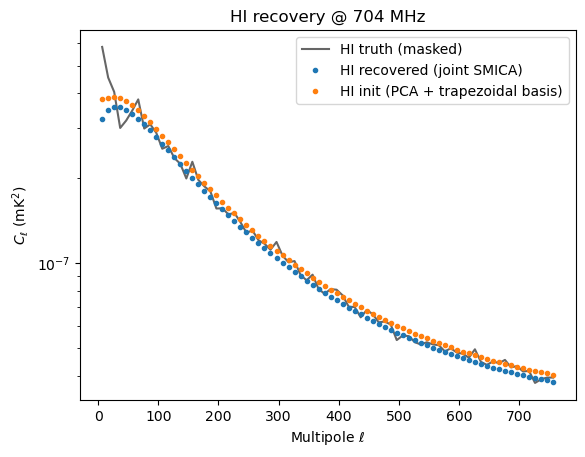

In [112]:
f = 16  # frequency channel index to inspect

plt.figure()
plt.plot(leff, hi_binned[:, f, f], 'k-', alpha=0.6, label='HI truth (masked)')
plt.plot(leff, C_HI_fit[:, f, f], '.', label='HI recovered (joint SMICA)')
plt.plot(leff, C_HI_init[:, f, f], '.', label='HI init (PCA + trapezoidal basis)')
plt.yscale('log')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$C_\ell$ (mK$^2$)')
plt.title(f'HI recovery @ {freqs[f]} MHz')
plt.legend()
plt.show()


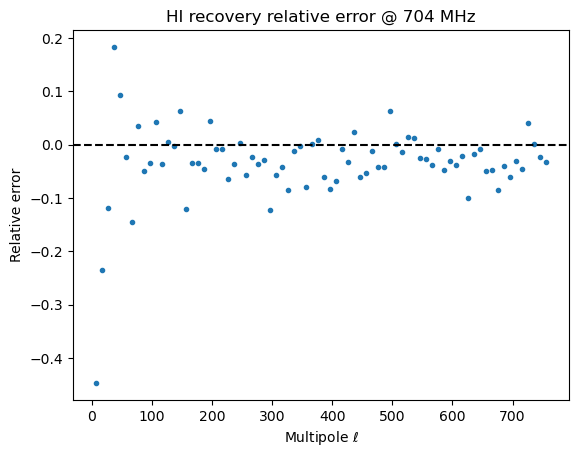

In [109]:
plt.figure()
plt.plot(leff, (C_HI_fit[:, f, f] - hi_binned[:, f, f]) / hi_binned[:, f, f], '.')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel('Relative error')
plt.title(f'HI recovery relative error @ {freqs[f]} MHz')
plt.show()


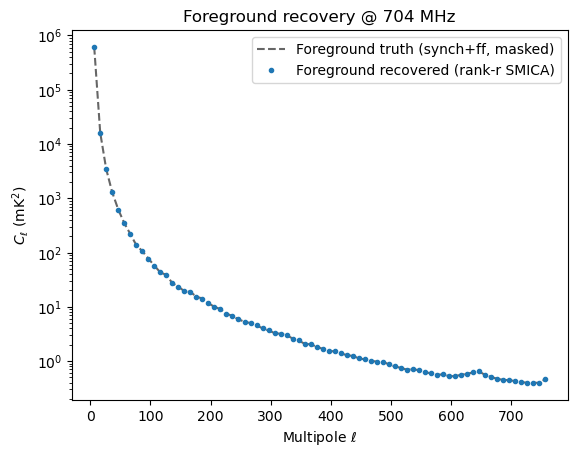

In [108]:
plt.figure()
plt.plot(leff, fgds_binned[:, f, f], 'k--', alpha=0.6, label='Foreground truth (synch+ff, masked)')
plt.plot(leff, C_FG_fit[:, f, f], '.', label='Foreground recovered (rank-r SMICA)')
plt.yscale('log')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$C_\ell$ (mK$^2$)')
plt.title(f'Foreground recovery @ {freqs[f]} MHz')
plt.legend()
plt.show()


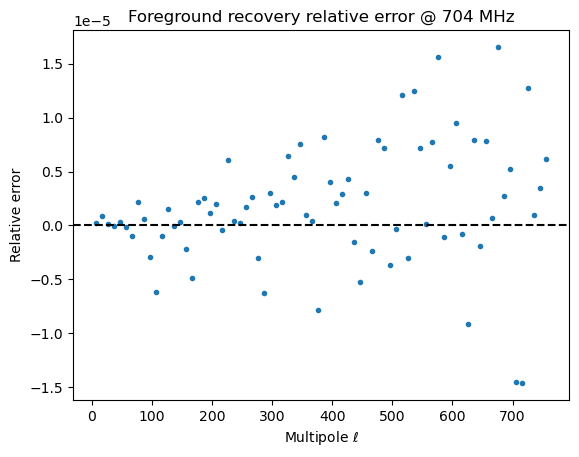

In [110]:
plt.figure()
plt.plot(leff, (C_FG_fit[:, f, f] - fgds_binned[:, f, f]) / fgds_binned[:, f, f], '.')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel('Relative error')
plt.title(f'Foreground recovery relative error @ {freqs[f]} MHz')
plt.show()


## HI parameter error bars

Fisher information for the HI block $a$, with the foreground and noise covariances fixed at their joint
best-fit values (i.e. these error bars do not yet marginalize over foreground/HI degeneracy -- they answer
"how well is $a$ constrained given the fitted foreground shape", matching the error-bar treatment already
used in `SMICA_HI.ipynb`, just with `C_FG_fit` in place of the oracle `fgds_binned`).

In [46]:
F_fisher = np.zeros((n_a, n_a))
for b in range(n_bins):
    M_inv = np.linalg.inv(C_total_fit[b])
    C_diag_b = np.diag(C_HI_fit[b])
    dRs = [np.diag(C_diag_b * (log_ell[b] ** p) * Psi[q]) for p, q in basis_terms]
    for m in range(n_a):
        A = M_inv @ dRs[m] @ M_inv
        for k in range(m, n_a):
            val = 0.5 * np.trace(A @ dRs[k])
            F_fisher[m, k] += val
            if k != m:
                F_fisher[k, m] += val

Sigma_a = np.linalg.inv(F_fisher)

sigma_C_HI = np.zeros((n_bins, nfreqs))
for b in range(n_bins):
    for v in range(nfreqs):
        J = np.array([log_ell[b] ** p * Psi[q, v] for p, q in basis_terms])
        sigma_C_HI[b, v] = C_HI_fit[b, v, v] * np.sqrt(J @ Sigma_a @ J)


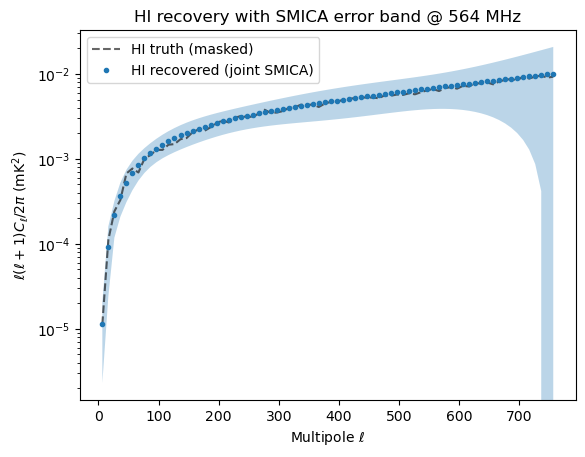

In [47]:
factor = leff * (leff + 1) / (2 * np.pi)
C_hi_d = factor * C_HI_fit[:, f, f]
C_hi_true_d = factor * hi_binned[:, f, f]
sigma_d = factor * sigma_C_HI[:, f]

fig, ax = plt.subplots()
ax.plot(leff, C_hi_true_d, 'k--', alpha=0.6, label='HI truth (masked)')
ax.plot(leff, C_hi_d, '.', label='HI recovered (joint SMICA)')
ax.fill_between(leff, C_hi_d - sigma_d, C_hi_d + sigma_d, alpha=0.3)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi$ (mK$^2$)')
ax.set_title(f'HI recovery with SMICA error band @ {freqs[f]} MHz')
ax.set_yscale('log')
ax.legend()
plt.show()


## Optional: naive PCA/SVD map-domain foreground cleaning

A quick, model-free visual sanity check (from `smica_test.ipynb`) -- subtract the top-`r` SVD modes of the
masked frequency$\times$pixel data cube directly in pixel space. This is a much blunter cut than the fitted
Wiener/GLS filter you'd build from `C_HI_fit` / `C_total_fit`, but useful as an independent cross-check that
the dominant sky modes really are foreground-dominated.

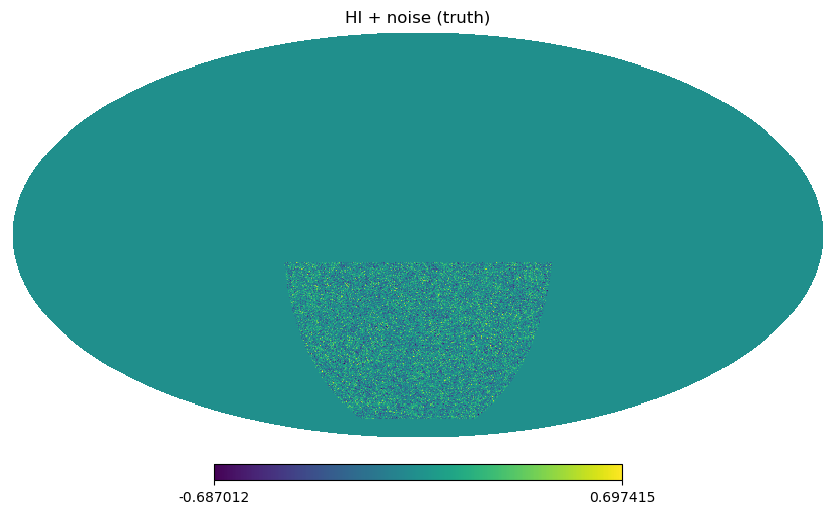

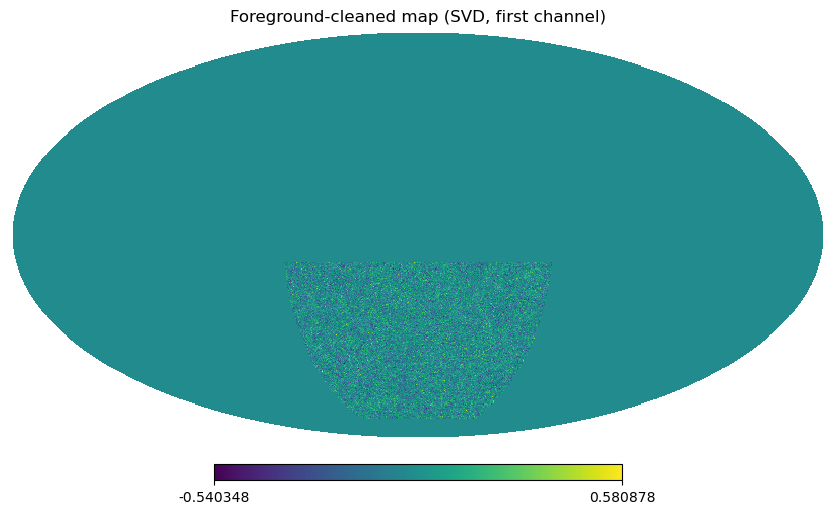

In [28]:
cube_clean = sky_masked - np.mean(sky_masked, axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(cube_clean, full_matrices=False)
n_modes = r
cube_fg_removed = cube_clean - (U[:, :n_modes] @ np.diag(S[:n_modes]) @ Vt[:n_modes, :])

hp.mollview(hi_masked[0] + noise_masked[0], title="HI + noise (truth)")
hp.mollview(cube_fg_removed[0], title="Foreground-cleaned map (SVD, first channel)")
